# Gadded — AI-Driven Solar Pre-Development Assessment

**AI Empower Egypt 2026 — Renewable Energy Using AI**

This notebook runs the full Gadded analytical engine end to end on one golden demo case:
a food-processing factory in 10th of Ramadan City evaluating an industrial rooftop solar
self-consumption system. It goes from raw inputs to a combined technical, financial,
regulatory, site, and vendor assessment — the same pipeline described in
`context/architecture-context.md`.

Every module is implemented in `src/gadded/` and independently unit-tested
(`pytest`, 112 tests). This notebook is the showcase that runs them together.
Two LLM providers are used, each for what it's actually good at: Gemini for grounded
regulatory reasoning and structured extraction, Groq for live web search (see
section 11 onward for why).

**Disclaimer:** This is a preliminary decision-support assessment. Verify regulatory,
engineering, grid, vendor, and financing information with the responsible authorities
and qualified professionals.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

import gadded
print("gadded package loaded from:", (ROOT / "src" / "gadded").resolve())
print("GEMINI_API_KEY set:", bool(os.environ.get("GEMINI_API_KEY")))


gadded package loaded from: C:\Users\yahia\OneDrive\Desktop\Gadded\src\gadded
GEMINI_API_KEY set: True


## 1. Input — the golden demo case

One fixed assessment, run start to finish: a food-processing factory in 10th of
Ramadan City's Industrial Zone C6, day-shift operation, 12 months of submitted
consumption, and a self-consumption grid-connection model. Keeping the case fixed
(rather than re-randomizing per run) makes every number below reproducible and
directly checkable against the module's own unit tests.

In [2]:
from gadded.contracts import load_assessment_input, load_assumptions

ai = load_assessment_input(ROOT / "data" / "golden_case.json")
a = load_assumptions(ROOT / "data" / "assumptions.json")

print("Project:", ai.projectName)
print("Location:", ai.location.address, f"({ai.location.latitude}, {ai.location.longitude})")
print("Sector / shift:", ai.factory.sector, "/", ai.factory.shiftPattern)
print("Connection model:", ai.connectionModel)
print("Roof area:", ai.site.availableRoofAreaM2, "m2, ownership:", ai.site.ownershipStatus)
print("Annual submitted consumption:", f"{sum(ai.factory.monthlyConsumptionKwh):,.0f} kWh")


Project: 10th of Ramadan Food Processing Rooftop Solar
Location: Industrial Zone C6 (المنطقة الصناعية ج6), 10th of Ramadan City, Egypt (30.3203, 31.7466)
Sector / shift: food_processing / day_shift
Connection model: self_consumption
Roof area: 3000.0 m2, ownership: owned
Annual submitted consumption: 1,963,000 kWh


## 2. Assumptions — versioned and classified

Every external or estimated value used below carries a source classification in
`data/assumptions.json`, so nothing here is presented as more certain than it is:

- `OFFICIAL` — published by the relevant Egyptian authority (e.g. the electricity
  tariff schedule).
- `MARKET_RANGE` — a real market price range from public vendor/bank sources, not a
  single verified quote.
- `LITERATURE_PROXY` — a standard engineering or financial rule of thumb (e.g.
  NREL's PVWatts loss stack).
- `SYNTHETIC` / `DEMO` — a hackathon placeholder that must be replaced with a
  sourced figure before any real-world use.

The table below shows the classification next to every number the rest of this
notebook actually uses.

In [3]:
rows = []
for key in ["capex_per_kw_egp", "opex_per_kw_year_egp", "discount_rate_pct",
            "tariff_retail_egp_per_kwh", "export_price_egp_per_kwh",
            "financing_rate_pct", "pv_tilt_degrees", "pv_system_loss_pct"]:
    v = a.values[key]
    rows.append({"assumption": key, "value": v.value, "unit": v.unit, "classification": v.classification})
pd.DataFrame(rows)


,assumption,value,unit,classification
0,capex_per_kw_egp,10000.000,EGP/kW,MARKET_RANGE
1,opex_per_kw_year_egp,500.000,EGP/kW/year,MARKET_RANGE
2,discount_rate_pct,12.000,percent,DEMO
3,tariff_retail_egp_per_kwh,2.550,EGP/kWh,OFFICIAL
4,export_price_egp_per_kwh,1.275,EGP/kWh,LITERATURE_PROXY
5,financing_rate_pct,20.000,percent/year,OFFICIAL
6,pv_tilt_degrees,25.000,degrees,LITERATURE_PROXY
7,pv_system_loss_pct,14.000,percent,LITERATURE_PROXY


## 3. Weather — NASA POWER (cached, real data)

Real hourly irradiance and temperature for the golden site's coordinates, fetched
once from NASA's POWER API and cached to CSV so the demo runs offline and
reproducibly (no live network call needed to grade this notebook). See
`src/gadded/weather.py`.

Source:

 NASA POWER Hourly | retrieved: 2026-07-28T09:36:08.323963+00:00
Rows: 8760 | timezone: Africa/Cairo
Warnings: none


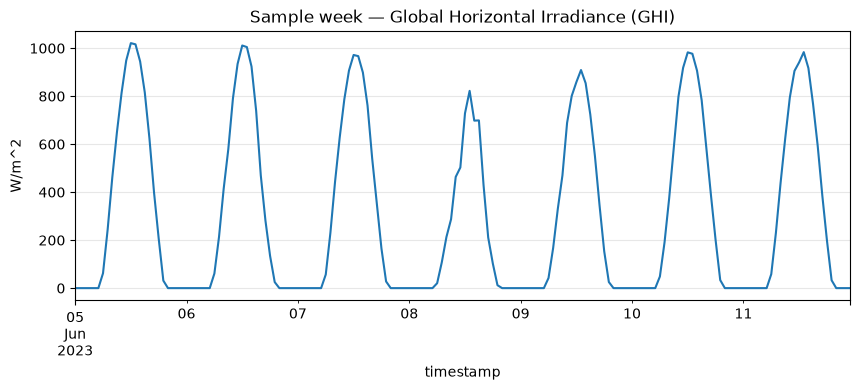

In [4]:
from gadded.weather import load_cached_weather

weather = load_cached_weather(ROOT / "data" / "weather_10ramadan_cached.csv")
print("Source:", weather.source_name, "| retrieved:", weather.retrieved_at)
print("Rows:", len(weather.frame), "| timezone:", weather.frame.index.tz)
print("Warnings:", weather.warnings or "none")

sample_week = weather.frame.loc["2023-06-05":"2023-06-11"]
sample_week["ghi_wm2"].plot(title="Sample week — Global Horizontal Irradiance (GHI)")
plt.ylabel("W/m^2")
plt.show()


## 4. Factory load profile — Machine Learning vs. deterministic baseline

**This is the real machine learning in Gadded.** `load.py`'s archetype baseline is a
fixed lookup, not ML. `load_ml.py` is:

1. A synthetic population of factories (parametric variants of six sector/shift
   archetypes, since no real Egyptian interval-metering data is available for this
   hackathon — clearly labeled synthetic throughout).
2. **KMeans clustering** on normalized weekly load shapes — cluster count chosen by
   silhouette score, not intuition.
3. A **RandomForest classifier** mapping simple user inputs (sector, shift pattern,
   working days, shift hours) to a cluster, evaluated on facilities held out at the
   *facility* level and compared against a majority-lookup baseline.
4. Low-confidence predictions fall back to the deterministic baseline automatically —
   never a weak ML guess.

In [5]:
from gadded.load import estimate_load_baseline
from gadded.load_ml import train_load_ml_model, predict_load_ml

tol = a.number("reconciliation_tolerance_pct")

bundle = train_load_ml_model(seed=42, n_per_combo=15)
print("Model:", bundle.version)
for k, v in bundle.metrics.items():
    print(f"  {k}: {v}")

ml_profile = predict_load_ml(ai, weather.frame.index, bundle, tol)
baseline_profile = estimate_load_baseline(ai, weather.frame.index, tol)

print("\nML prediction  -> confidence:", ml_profile.result.confidence,
      "| model:", ml_profile.result.modelVersion,
      "| reconciliation error: %.4f%%" % ml_profile.result.reconciliationErrorPct)
print("Baseline       -> confidence:", baseline_profile.result.confidence,
      "| reconciliation error: %.4f%%" % baseline_profile.result.reconciliationErrorPct)


Model: load-cluster-classifier-0.1.0
  chosen_k: 6
  train_facility_count: 67
  test_facility_count: 23
  classifier_test_accuracy: 0.9565217391304348
  baseline_test_accuracy: 0.9130434782608695
  silhouette_score_train: 0.428027557705337
  adjusted_rand_index_vs_combo_label: 0.6532663316582915
  seed: 42
  limitations: Trained entirely on a synthetic parametric population, not measured Egyptian factory interval data. Cluster recovery validates the clustering+classification technique; it is not a discovery of real hidden structure.

ML prediction  -> confidence: high | model: load-cluster-classifier-0.1.0 | reconciliation error: 0.0000%
Baseline       -> confidence: low | reconciliation error: 0.0000%


The chart below is the same week shown two ways: the ML-predicted load shape from
`load_ml.py` versus the deterministic archetype baseline from `load.py`. They
should look similar in overall pattern (both reconcile exactly to the same
submitted monthly kWh) but differ in shape detail — that shape detail is what the
ML model actually learned.

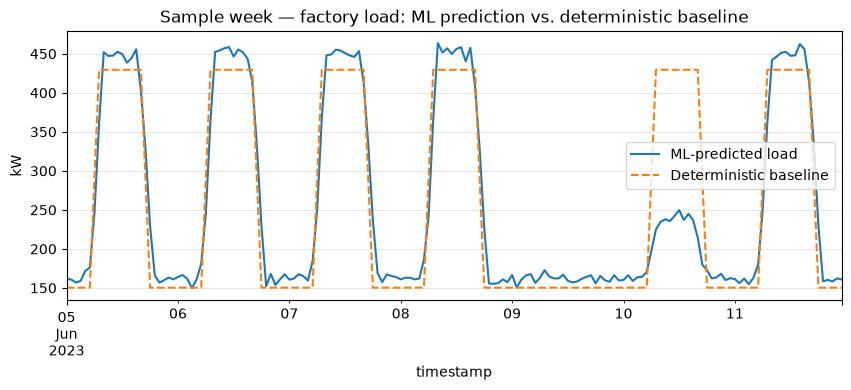

In [6]:
sample = slice("2023-06-05", "2023-06-11")
fig, ax = plt.subplots()
ml_profile.series.loc[sample]["load_kw"].plot(ax=ax, label="ML-predicted load")
baseline_profile.series.loc[sample]["load_kw"].plot(ax=ax, label="Deterministic baseline", linestyle="--")
ax.set_ylabel("kW")
ax.set_title("Sample week — factory load: ML prediction vs. deterministic baseline")
ax.legend()
plt.show()

load_profile = ml_profile  # used downstream


## 5. PV generation — physics (`pvlib`), not machine learning

Hourly AC generation from plane-of-array irradiance transposition (Hay-Davies), cell
temperature (Faiman), and the PVWatts DC model, with a system-loss derate. Deterministic
and reproducible from the same weather and assumptions — this is engineering simulation,
never described as ML.

500 kW demo system -> 874,214 kWh/yr (1,748 kWh/kWp specific yield)


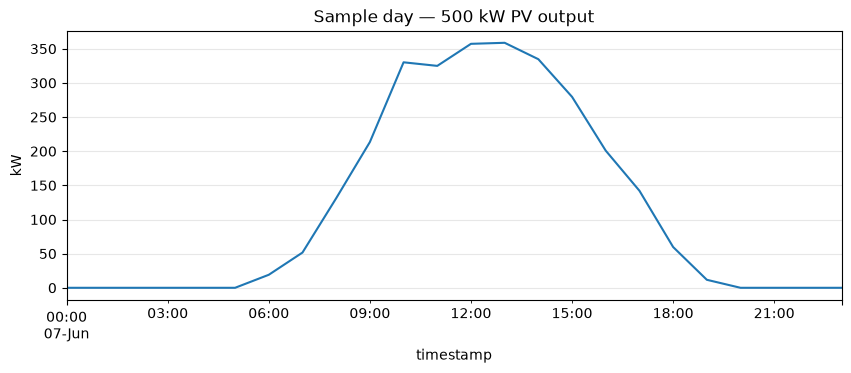

In [7]:
from gadded.pv import generate_pv

demo_pv = generate_pv(weather, 500, a)
specific_yield = demo_pv.result.annualGenerationKwh / 500
print(f"500 kW demo system -> {demo_pv.result.annualGenerationKwh:,.0f} kWh/yr "
      f"({specific_yield:,.0f} kWh/kWp specific yield)")

demo_pv.series.loc["2023-06-07"]["pv_kw"].plot(title="Sample day — 500 kW PV output")
plt.ylabel("kW")
plt.show()


## 6. Sizing optimization — constrained NPV search

Candidate capacities are generated from the roof area (and budget, if given); each is
evaluated by project NPV using the *same* PV and load models above. The recommendation is
not simply the largest system that fits the roof — the chart below shows where the
economic optimum actually falls.

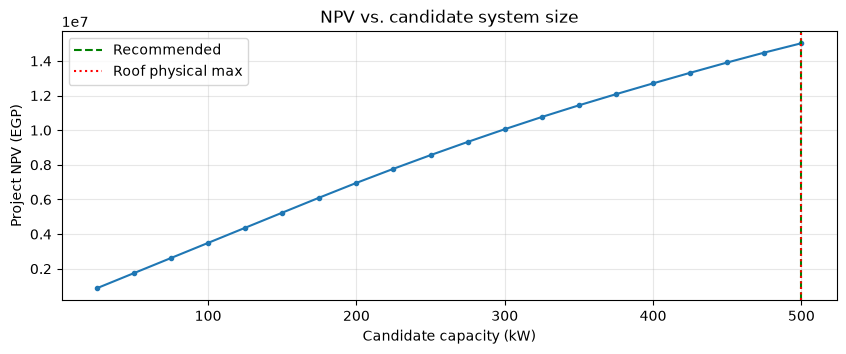

Recommended capacity: 500 kW (physical roof maximum: 500 kW)
Binding constraint(s): roof_area
Annual generation: 874,214 kWh | self-consumption: 90.0% | self-sufficiency: 40.1%


In [8]:
from gadded.optimization import optimize_capacity

opt = optimize_capacity(ai, weather, load_profile.series["load_kw"], a)
rec = opt.recommendation

fig, ax = plt.subplots()
ax.plot(opt.table["capacity_kw"], opt.table["npv_egp"], marker="o", markersize=3)
ax.axvline(rec.recommendedCapacityKw, color="green", linestyle="--", label="Recommended")
ax.axvline(rec.physicalMaximumKw, color="red", linestyle=":", label="Roof physical max")
ax.set_xlabel("Candidate capacity (kW)")
ax.set_ylabel("Project NPV (EGP)")
ax.set_title("NPV vs. candidate system size")
ax.legend()
plt.show()

print(f"Recommended capacity: {rec.recommendedCapacityKw:.0f} kW "
      f"(physical roof maximum: {rec.physicalMaximumKw:.0f} kW)")
print("Binding constraint(s):", ", ".join(rec.bindingConstraints))
print(f"Annual generation: {rec.annualGenerationKwh:,.0f} kWh | "
      f"self-consumption: {rec.selfConsumptionRatio*100:.1f}% | "
      f"self-sufficiency: {rec.selfSufficiencyRatio*100:.1f}%")


## 7. Load vs. PV matching at the recommended capacity

Hour-by-hour self-consumed / imported / exported energy, using the canonical
equations in `data-contracts.md` (`self_consumed = min(load, pv)`, etc.). This step
matters specifically because the factory is on a **self-consumption** connection
model: exported (spilled) solar isn't compensated, so the whole financial case rests
on how much PV output actually lands inside hours the factory is already drawing
power — not on total generation alone.

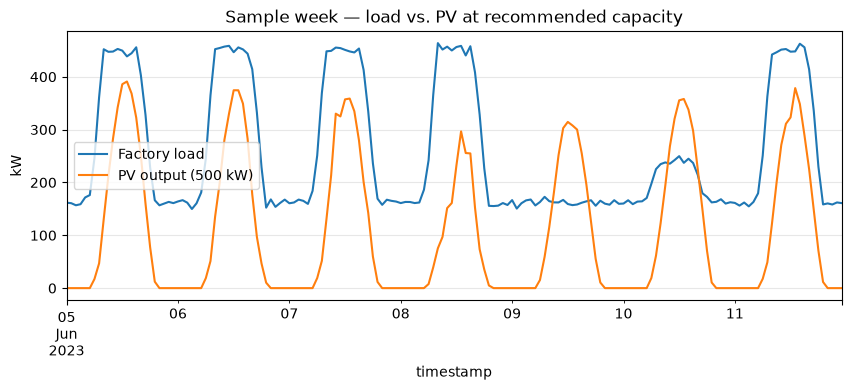

Annual load: 1,963,000 kWh | annual PV: 874,214 kWh
Self-consumed: 786,963 kWh | imported: 1,176,037 kWh | exported (spilled): 87,252 kWh
Retail value avoided: 2,006,755 EGP/yr


In [9]:
best = opt.best_match
row = opt.table.loc[rec.recommendedCapacityKw]

sample = slice("2023-06-05", "2023-06-11")
fig, ax = plt.subplots()
best.hourly.loc[sample]["load_kw"].plot(ax=ax, label="Factory load")
best.hourly.loc[sample]["pv_kw"].plot(ax=ax, label=f"PV output ({rec.recommendedCapacityKw:.0f} kW)")
ax.set_ylabel("kW")
ax.set_title("Sample week — load vs. PV at recommended capacity")
ax.legend()
plt.show()

print(f"Annual load: {best.annual_load_kwh:,.0f} kWh | annual PV: {best.annual_pv_kwh:,.0f} kWh")
print(f"Self-consumed: {best.annual_self_kwh:,.0f} kWh | imported: {best.annual_import_kwh:,.0f} kWh "
      f"| exported (spilled): {best.annual_export_kwh:,.0f} kWh")
print(f"Retail value avoided: {best.annual_retail_value_egp:,.0f} EGP/yr")


## 8. Financial scenarios — cash vs. finance (deterministic)

NPV, IRR, and simple/discounted payback for both an all-cash purchase and a
debt-financed purchase. Formulas are unit-tested independently (`tests/test_finance.py`);
Monte Carlo (next section) reuses these exact functions per simulated draw.

In [10]:
from gadded.finance import build_scenarios

scenarios = build_scenarios(rec.recommendedCapacityKw, row["year1_savings_egp"], a, ai.finance.preference)
pd.DataFrame([{
    "scenario": s.scenario,
    "capex_egp": round(s.capexEgp),
    "npv_egp": round(s.npvEgp),
    "irr_pct": round(s.irrPct, 1) if s.irrPct is not None else None,
    "simple_payback_yr": round(s.simplePaybackYears, 2) if s.simplePaybackYears else None,
    "discounted_payback_yr": round(s.discountedPaybackYears, 2) if s.discountedPaybackYears else None,
    "monthly_loan_egp": round(s.monthlyLoanPaymentEgp) if s.monthlyLoanPaymentEgp else None,
} for s in scenarios])


,scenario,capex_egp,npv_egp,irr_pct,simple_payback_yr,discounted_payback_yr,monthly_loan_egp
0,cash,5000000,15020574,40.1,2.72,3.45,NaN
1,finance,5000000,14106077,79.0,1.46,1.70,88825.0


## 9. Risk — Monte Carlo uncertainty

The financial result is reported as a **range**, not a single deterministic payback
number. 2,000 seeded simulations vary PV yield, capex, opex, and tariff escalation,
reusing the exact deterministic finance functions above for every draw. Sensitivity is
computed by perturbing each variable one at a time.

In [11]:
from gadded.risk import RiskInputs, run_monte_carlo

risk_inputs = RiskInputs(
    capacity_kw=rec.recommendedCapacityKw,
    year1_pv_savings_egp=row["year1_savings_egp"],
    capex_egp=row["capex_egp"],
    opex_egp=rec.recommendedCapacityKw * a.number("opex_per_kw_year_egp"),
)
risk = run_monte_carlo(
    risk_inputs, a,
    target_payback_years=ai.finance.targetPaybackYears,
    seed=int(a.number("monte_carlo_seed")),
    runs=int(a.number("monte_carlo_runs")),
)

print(f"NPV  P10/P50/P90: {risk.npvP10Egp:,.0f} / {risk.npvP50Egp:,.0f} / {risk.npvP90Egp:,.0f} EGP")
print(f"Payback P10/P50/P90: {risk.paybackP10Years:.1f} / {risk.paybackP50Years:.1f} / {risk.paybackP90Years:.1f} years")
if risk.probabilityTargetPaybackPct is not None:
    print(f"Probability of meeting the {ai.finance.targetPaybackYears}-year target payback: "
          f"{risk.probabilityTargetPaybackPct:.1f}%")
print("Top sensitivity drivers:", [(d.variable, round(d.influence*100, 1)) for d in risk.topSensitivityDrivers])


NPV  P10/P50/P90: 10,735,896 / 14,844,303 / 20,642,210 EGP
Payback P10/P50/P90: 2.4 / 2.7 / 3.1 years
Probability of meeting the 6.0-year target payback: 100.0%
Top sensitivity drivers: [('tariff_escalation', 68.2), ('pv_yield', 18.5), ('capex', 8.4), ('opex', 4.9)]


Two views of the same Monte Carlo run: which input variable moves the result the
most (sensitivity), and the resulting spread of possible project NPV outcomes
(P10/P50/P90). A wide gap between P10 and P90 means the project's uncertainty is
real and should be disclosed as a range — not smoothed into one headline number.

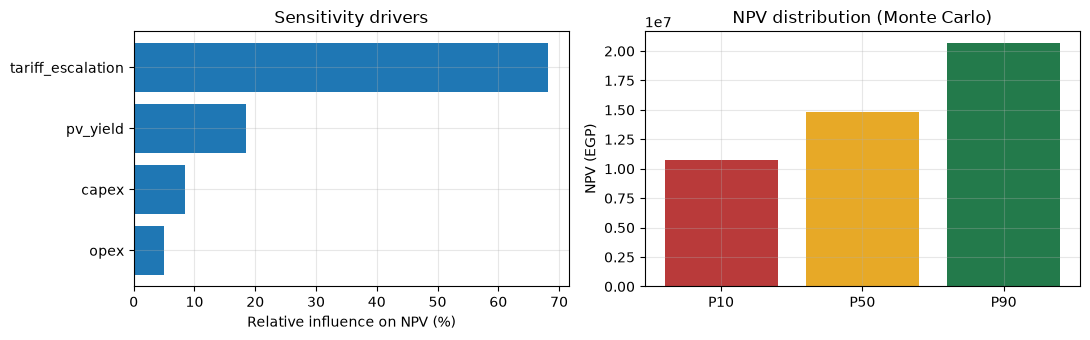

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
drivers = risk.topSensitivityDrivers
axes[0].barh([d.variable for d in drivers][::-1], [d.influence*100 for d in drivers][::-1])
axes[0].set_xlabel("Relative influence on NPV (%)")
axes[0].set_title("Sensitivity drivers")

axes[1].bar(["P10", "P50", "P90"], [risk.npvP10Egp, risk.npvP50Egp, risk.npvP90Egp],
            color=["#B93A3A", "#E7A927", "#237A4B"])
axes[1].set_ylabel("NPV (EGP)")
axes[1].set_title("NPV distribution (Monte Carlo)")
plt.tight_layout()
plt.show()


## 10. Site screening — GIS (Shapely, real + labeled-synthetic layers)

Point-in-polygon and nearest-distance checks against `data/zones.geojson`, which
mixes **real** data — all 47 official WDPA/UNEP-WCMC Egyptian protected-area
polygons, plus industrial-zone, road, and substation geometry pulled from
OpenStreetMap — with exactly one clearly-labeled synthetic demo polygon (kept only
so the interactive "protected area" preset in the Streamlit app still has something
nearby to trigger against). The manifest's `source_class` field states which is
which for every layer. Missing coverage returns `unknown`, never `clear` — using
PostGIS or an authoritative Egyptian GIS service in production would remove the one
synthetic layer, not change this logic.

In [13]:
from gadded.gis import load_zones, screen_site

zones = load_zones(ROOT / "data" / "zones.geojson")
gis_findings = screen_site(ai.location.latitude, ai.location.longitude, zones)

pd.DataFrame([{
    "category": f.category, "severity": f.severity, "title": f.title,
    "value": f.value, "unit": f.unit, "source": f.sourceName,
} for f in gis_findings])


,category,severity,title,value,unit,source
0,industrial_zone,info,Site is inside 10th of Ramadan City Industrial...,10th of Ramadan City Industrial Zone (OpenStre...,NaN,"OpenStreetMap (via Overpass API), landuse=indu..."
1,protected_area,info,Site does not intersect any mapped protected area,False,NaN,gadded-gis-layers
2,substation_distance,info,Nearest mapped substation: OSM power=substatio...,3361.1,m,"OpenStreetMap (via Overpass API), power=substa..."
3,road_distance,info,Nearest mapped road: طريق الإسماعيلية,5808.4,m,"OpenStreetMap (via Overpass API), highway=trun..."


## 11. Regulatory — retrieval + deterministic rules + cited LLM explanation

`data/regulations/excerpts.json` and `rules.json` cite **real** Egyptian regulatory
sources — EgyptERA Circulars 3/2023, 6/2023, and 4/2026, the Renewable Energy Law
203/2014, the Protected Areas Law 102/1983, and Environmental Law 4/1994/EEAA
guidance — paraphrased from public research, not verbatim legal text (see each
excerpt's `sourceUrl` and effective date). Three separate layers evaluate them,
never merged:

1. **Retrieval** — LLM relevance scoring (Gemini, JSON-scored) over the excerpt
   corpus, falling back to TF-IDF cosine similarity when no client is available or
   the LLM call fails, so retrieval always works offline.
2. **Deterministic rules** (`rules.json`) decide the actual conclusion, severity,
   and citations — evaluated with a safe dict-based condition DSL, no `eval`.
3. An **LLM explanation** (Gemini), grounded strictly in the retrieved text and the
   rule conclusions above. It may summarize; it may never invent a permit,
   threshold, authority, or duration.

In [14]:
from gadded.regulatory import build_context, evaluate_rules, load_excerpts, load_rules, retrieve

corpus = load_excerpts(ROOT / "data" / "regulations" / "excerpts.json")
rules = load_rules(ROOT / "data" / "regulations" / "rules.json")

reg_ctx = build_context(
    ai.connectionModel, ai.site.ownershipStatus,
    {f.code for f in gis_findings}, rec.recommendedCapacityKw,
)
reg_findings = evaluate_rules(reg_ctx, rules, corpus)

for f in reg_findings:
    print(f"[{f.conclusion} | {f.severity} | confidence={f.confidence}] {f.title}")
    print(" ", f.explanation)


[applicable | info | confidence=high] Self-consumption connection is supported at this capacity
  At this capacity (up to 500 kW) a subscriber-owned self-consumption plant may qualify for an exemption from the electricity-generation permit and licence. The plant must not export power to the grid and must be installed by an NREA-qualified company.
[requires_review | warning | confidence=medium] EEAA environmental-impact assessment required
  Industrial solar installations require EEAA environmental review before construction or operation; the residential exemption does not apply. Compact solar installations are typically handled as a Category B project (commonly reviewed within about 30 days), though the final classification depends on plant capacity, location, and environmental sensitivity.


With the deterministic findings already fixed above, ask an LLM to explain them in
plain language — grounded only in the retrieved excerpt text and the rule output
it's given, so it can't introduce a fact the deterministic layers didn't already
establish.

In [15]:
import os
question = "Can this factory install a self-consumption rooftop solar system?"

if os.environ.get("GEMINI_API_KEY"):
    try:
        from google import genai
        from gadded.regulatory import explain_with_llm

        client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
        retrieved = retrieve(question, corpus, top_k=2, client=client)
        explanation = explain_with_llm(question, retrieved, reg_findings, client)
        print("LLM explanation (grounded in the excerpts/rules above):\n")
        print(explanation or "(no explanation returned)")
    except Exception as e:
        print(f"Regulatory LLM explanation unavailable this run ({type(e).__name__}); "
              "deterministic rule findings above are unaffected.")
        explanation = None
else:
    retrieved = retrieve(question, corpus, top_k=2)
    print("GEMINI_API_KEY not set — skipping the live LLM explanation call. "
          "Deterministic rule findings above still stand on their own.")
    explanation = None


LLM explanation (grounded in the excerpts/rules above):

Yes, your factory can install a self-consumption rooftop solar system, provided it supplies your internal load without exporting electricity to the public grid and does not exceed your previous financial year's maximum load or 30 MW. The project must be implemented by an NREA-qualified company and complies with applicable electrical and safety codes, though an EEAA environmental-impact assessment is required. Depending on the system's capacity and whether you own the plant or use a power-purchase agreement, you may also need an EgyptERA construction permit, an electricity-generation licence, and a grid-impact study.


## 12. Vendor discovery — LLM web-search agent (evidence-gated)

Two stages, two providers: Groq's `groq/compound` runs a real web search
server-side (Gemini's own Google Search grounding needs a billing-enabled Google
Cloud project, so it isn't used here); a second, plain JSON-mode Gemini call then
extracts strict, evidence-backed vendor candidates from only that search output. No
candidate is kept without at least one source URL; no quality-ranking language
("best", "certified", etc.) is allowed; both stages fail soft — a vendor-search
outage never invalidates the technical/financial result above.

In [16]:
if os.environ.get("GEMINI_API_KEY") and os.environ.get("GROQ_API_KEY"):
    try:
        from google import genai
        from openai import OpenAI
        from gadded.vendors import discover_vendors

        extraction_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
        search_client = OpenAI(api_key=os.environ["GROQ_API_KEY"],
                                base_url="https://api.groq.com/openai/v1",
                                timeout=90.0, max_retries=1)
        vendors, vendor_warnings = discover_vendors(
            ai.location.address or "10th of Ramadan City, Egypt",
            rec.recommendedCapacityKw, ai.connectionModel, search_client, extraction_client, max_candidates=5,
        )
        print(f"{len(vendors)} vendor candidate(s), {len(vendor_warnings)} warning(s)")
        for w in vendor_warnings:
            print(" warning:", w)
        for v in vendors:
            print(f"- {v.name} ({v.websiteUrl}) - {v.verificationStatus}")
            print(" ", v.fitExplanation)
            print("  evidence:", v.evidence[0].url)
    except Exception as e:
        print(f"Vendor discovery unavailable this run ({type(e).__name__}); "
              "this is expected to fail soft and does not affect the result above.")
        vendors, vendor_warnings = [], [f"vendor discovery failed: {type(e).__name__}"]
else:
    print("GEMINI_API_KEY and GROQ_API_KEY both required - skipping live vendor discovery.")
    vendors, vendor_warnings = [], ["vendor discovery skipped: missing API key"]


0 vendor candidate(s), 4 warning(s)


## 13. Overall feasibility — deterministic status

A fixed, ordered waterfall over the regulatory findings, GIS findings, and any
*run-specific* module warnings decides the final status. Financial performance is
reported separately (above) and never changes this label — the LLM never decides
feasibility.

In [17]:
from gadded.feasibility import resolve_feasibility

# Only run-specific anomalies feed the status decision, not standing PoC-model
# disclosures like "synthetic baseline" (those stay visible in warnings below).
material_warnings = [
    w for w in load_profile.result.warnings
    if "exceeds tolerance" in w or "empty archetype shape" in w
]
feas = resolve_feasibility(reg_findings, gis_findings, ai.site.ownershipStatus, material_warnings)

print("Overall status:", feas.status)
for r in feas.reasons:
    print(" -", r)


Overall status: feasible_with_conditions
 - regulatory finding RULE-008 requires review


## 14. Combined report

Assembled entirely from the structured results already computed above — no
recomputation — and rendered as a self-contained HTML report with citations, versions,
and the standard disclaimer.

In [18]:
from gadded.contracts import ResultVersions
from gadded.report import assemble_result, render_html
from datetime import datetime, timezone

versions = ResultVersions(
    code="gadded-poc-0.1.0",
    assumptionSet=a.assumptionSet.id,
    loadModel=load_profile.result.modelVersion,
    pvModel="pvlib-pvwatts-0.1.0",
    regulatoryPrompt="reg-explain-0.1.0",
    vendorPrompt="vendor-discovery-0.1.0",
)

all_warnings = list(load_profile.result.warnings) + list(vendor_warnings)

result = assemble_result(
    run_id=f"run-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')}",
    assessment_id=ai.projectId,
    status=feas.status,
    technical=rec,
    financial=scenarios,
    risk=risk,
    gis_findings=gis_findings,
    regulatory_findings=reg_findings,
    vendors=vendors,
    warnings=all_warnings,
    versions=versions,
)

generated_at = datetime.now(timezone.utc).isoformat()
html = render_html(result, ai.projectName, generated_at)

out_path = ROOT / "docs" / "example_report.html"
out_path.parent.mkdir(exist_ok=True)
out_path.write_text(html, encoding="utf-8")
print("Report written to:", out_path)
print("Status:", result.status, "| recommended capacity:", result.technical.recommendedCapacityKw, "kW")


Report written to: C:\Users\yahia\OneDrive\Desktop\Gadded\docs\example_report.html
Status: feasible_with_conditions | recommended capacity: 500.0 kW


Render the same self-contained HTML report inline here, so the full assessment —
citations, versions, disclaimer included — is visible without leaving the
notebook.

In [19]:
from IPython.display import HTML, display
display(HTML(html))


## Summary — what is ML, physics, optimization, simulation, rules, and LLM orchestration

| Component | Category | Module |
|---|---|---|
| Factory load shape (baseline) | Deterministic lookup (not ML) | `load.py` |
| Factory load shape (learned) | **Machine learning** — KMeans clustering + RandomForest classifier | `load_ml.py` |
| PV generation | Physics / engineering simulation (`pvlib`) | `pv.py` |
| System sizing | Constrained optimization (NPV grid search) | `optimization.py` |
| Cash/finance scenarios | Deterministic finance formulas | `finance.py` |
| Uncertainty ranges | Monte Carlo simulation | `risk.py` |
| Site screening | Geospatial rules (Shapely) | `gis.py` |
| Regulatory retrieval | LLM relevance scoring, TF-IDF fallback | `regulatory.py` |
| Regulatory conclusion | Deterministic rule engine | `regulatory.py` |
| Regulatory explanation | LLM, grounded/cited only | `regulatory.py` (Gemini) |
| Vendor discovery | LLM web-search agent, evidence-gated | `vendors.py` (Groq search + Gemini extraction) |
| Overall feasibility | Deterministic waterfall (never the LLM) | `feasibility.py` |

## Limitations

- Load profile is either a synthetic-trained ML model or a synthetic deterministic
  baseline — neither is trained on measured Egyptian factory interval data (none
  was available for this hackathon timebox).
- GIS layers are mostly **real**: all 47 official WDPA protected-area polygons for
  Egypt, plus OpenStreetMap-derived industrial-zone/road/substation geometry, with
  exactly one clearly-labeled synthetic demo polygon retained for the Streamlit
  app's interactive "protected area" preset.
- Regulatory excerpts cite **real** EgyptERA circulars and Egyptian law, paraphrased
  from public research rather than verbatim legal text — verify current effective
  dates and exact wording with EgyptERA/a qualified professional before relying on
  them.
- Several financial assumptions (discount rate, some Monte Carlo variability
  widths) are still DEMO/SYNTHETIC values — see `data/assumptions.json` for the
  classification of every number used above; capex, tariffs, and financing terms
  are sourced to real market/bank/official figures.
- Regulatory-LLM and vendor-search stages depend on live Gemini/Groq API calls and
  fail soft — a provider outage or rate limit removes that stage's output but never
  changes the deterministic technical, financial, or feasibility results above.

**This is a preliminary decision-support assessment. Verify regulatory, engineering,
grid, vendor, and financing information with the responsible authorities and qualified
professionals.**